<a href="https://colab.research.google.com/github/khush2705/ML_safety/blob/main/Exercise_07/MLSafety_Exercise_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

# Paths
BASE  = "/content/drive/MyDrive/MLSafety"
TRAIN = f"{BASE}/train"
TEST  = f"{BASE}/test"
FOG   = f"{BASE}/test-fog"
NIGHT = f"{BASE}/test-night"
TOWN  = f"{BASE}/test-town-01"

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Standard transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("Setup complete.")

Device: cuda
Setup complete.


In [ ]:
def show_images(folder, title):
    df = pd.read_csv(f"{folder}/labels.csv")
    frames = df["frame"].head(5).tolist()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, frame in enumerate(frames):
        img_path = f"{folder}/rgb-front/{str(frame).zfill(6)}.jpg"
        img = Image.open(img_path).convert("RGB")
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Frame {frame}", fontsize=9)

    plt.tight_layout()
    plt.show()

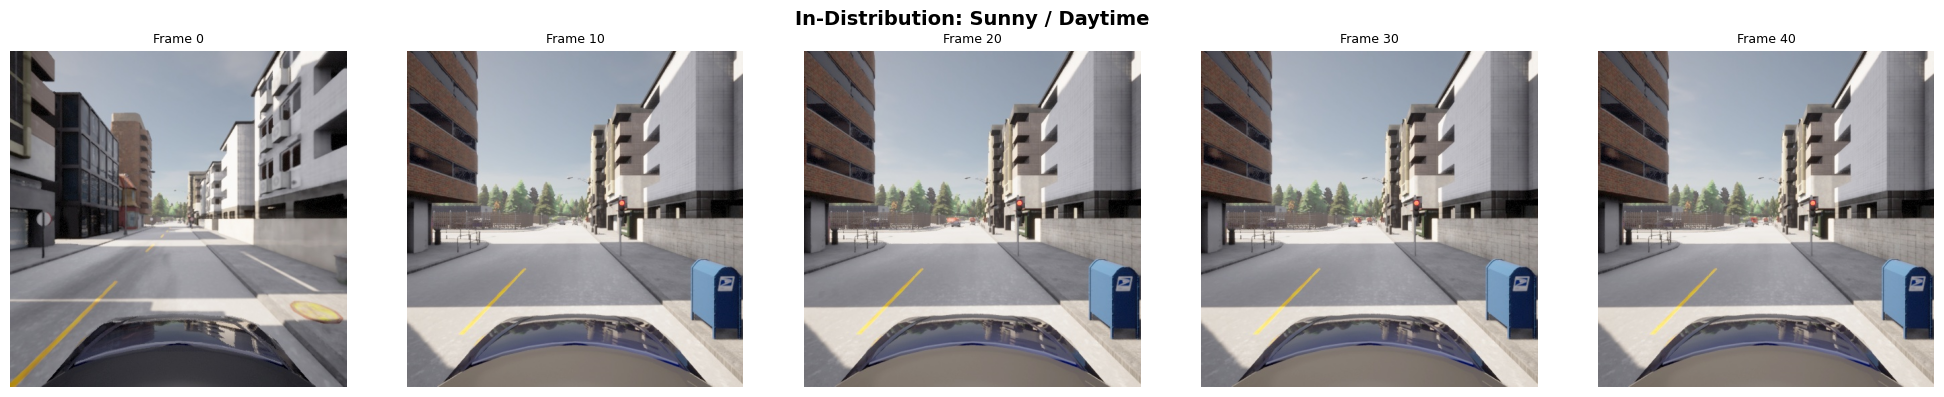

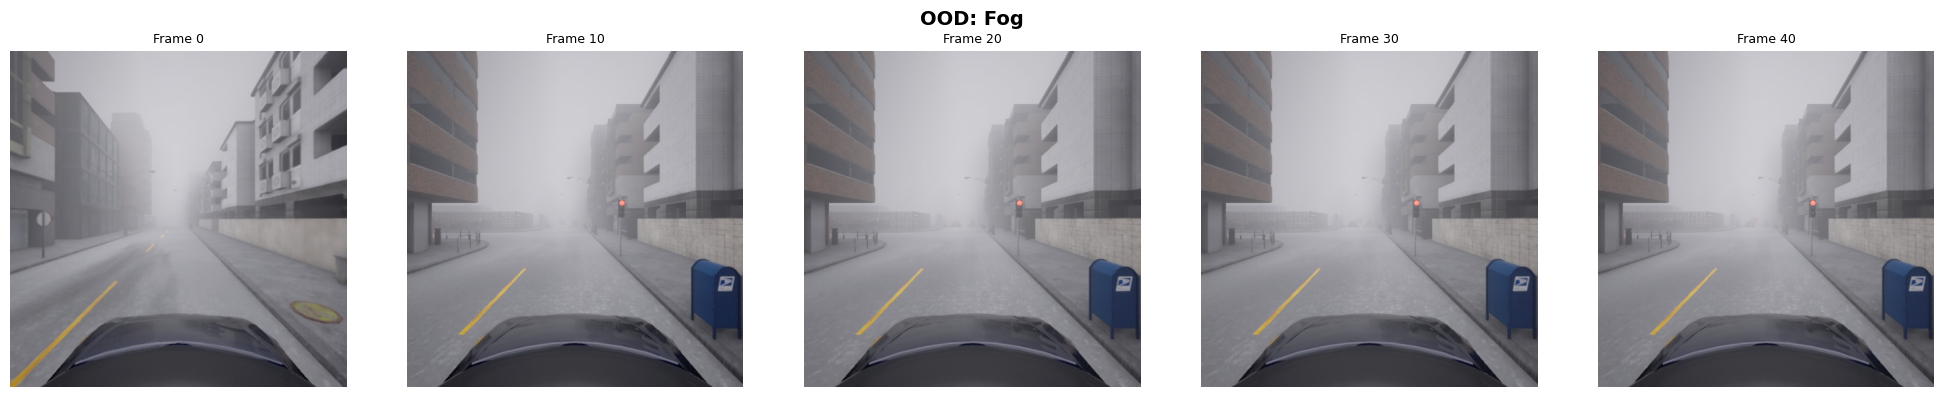

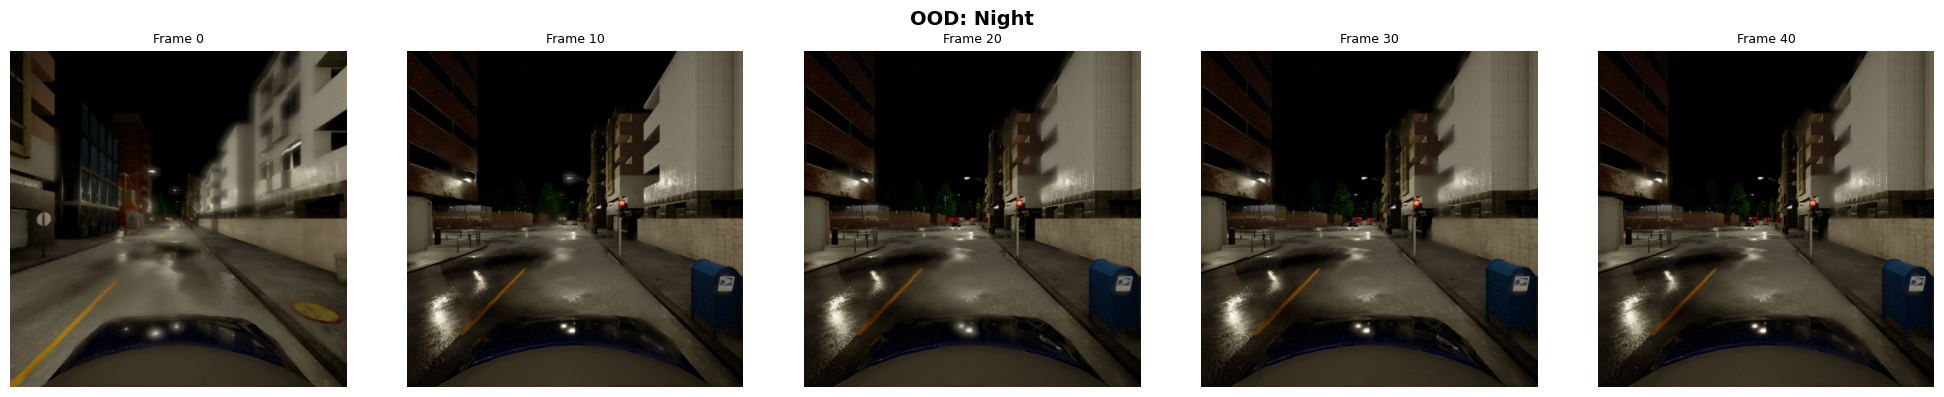

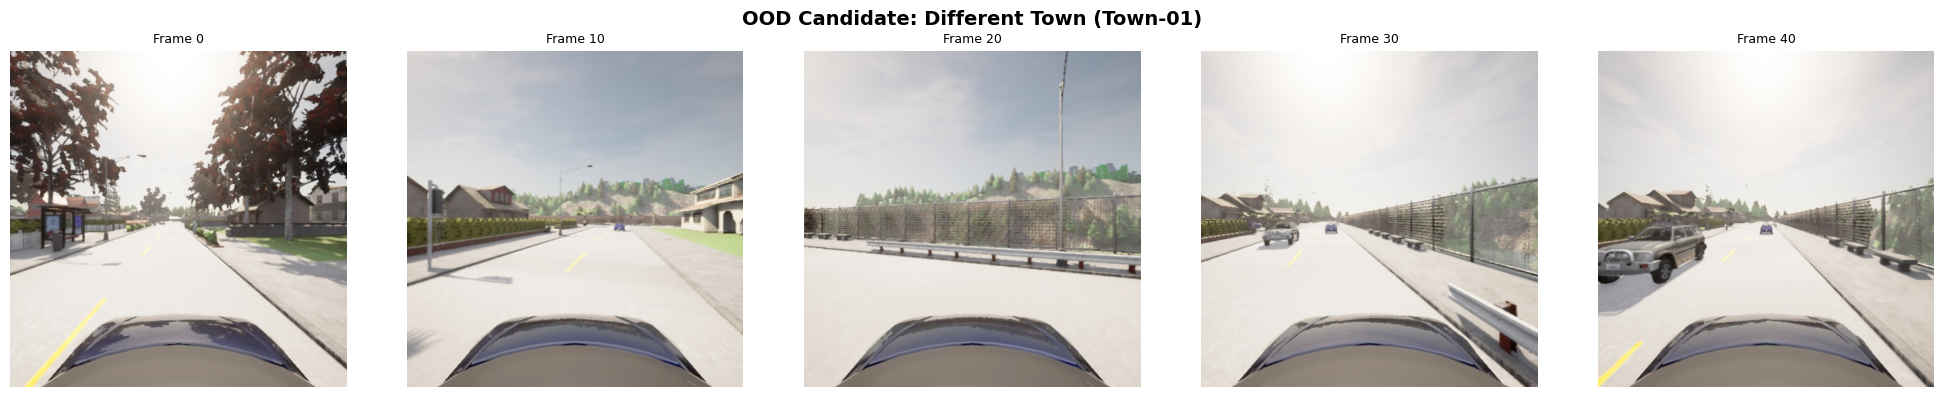

In [ ]:
show_images(TEST,  "In-Distribution: Sunny / Daytime")
show_images(FOG,   "OOD: Fog")
show_images(NIGHT, "OOD: Night")
show_images(TOWN,  "OOD Candidate: Different Town (Town-01)")

Fog vs Sunny: The fog images are captured in the same town with the same road geometry and scene layout as the training (sunny) images. The difference is purely a low-level pixel-level shift — reduced contrast, washed-out colours, and a grey haze that obscures distant objects. The overall structure (buildings, road markings, mailboxes) is still recognisable.

Night vs Sunny: The night images show the same town under artificial lighting. The global pixel distribution changes drastically — the image is predominantly dark with bright point-light sources and wet road reflections. This is a stronger low-level shift than fog, as most of the scene detail is lost.

Different Town vs Sunny: The different-town images look visually "normal" — clear daytime lighting, good visibility — but the scene content is entirely different. The training town is dense urban (tall apartment buildings, narrow roads, city infrastructure). Town-01 is suburban (low houses, wide open roads, fences, large trees, highway-style geometry). There are no tall buildings, no city mailboxes, and the road layout is completely unlike the training environment.

Key comparison: Fog and night are perceptual shifts — the same world seen through a degraded sensor. The different town is a semantic/structural shift — a visually clean image of a world the model has never seen. This makes the town shift potentially more dangerous: there are no obvious visual cues that anything is wrong, so neither a human observer nor a naive OOD detector would immediately flag it.


In [ ]:
def load_model(path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

ped_model     = load_model(f"{BASE}/model_outputs/best_has_pedestrian.pth")
vehicle_model = load_model(f"{BASE}/model_outputs/best_has_vehicle.pth")
traffic_model = load_model(f"{BASE}/model_outputs/best_has_traffic_light.pth")

print("All three models loaded successfully.")

All three models loaded successfully.


In [ ]:
def mean_confidence(folder, model):
    df = pd.read_csv(f"{folder}/labels.csv")
    confidences = []

    for _, row in df.iterrows():
        frame    = str(row["frame"]).zfill(6)
        img_path = f"{folder}/rgb-front/{frame}.jpg"
        img      = Image.open(img_path).convert("RGB")
        x        = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).item()

        confidences.append(prob)

    return np.mean(confidences)

# Compute for all three datasets x all three models
datasets = {"Sunny (In-Dist)": TEST, "Fog (OOD)": FOG, "Night (OOD)": NIGHT}
results  = []

for name, folder in datasets.items():
    print(f"Processing {name}...")
    ped_conf     = mean_confidence(folder, ped_model)
    vehicle_conf = mean_confidence(folder, vehicle_model)
    traffic_conf = mean_confidence(folder, traffic_model)
    results.append([name, ped_conf, vehicle_conf, traffic_conf])

confidence_df = pd.DataFrame(
    results,
    columns=["Dataset", "Pedestrian Model", "Vehicle Model", "Traffic Light Model"]
)

print("\n--- Mean Softmax Confidence ---")
print(confidence_df.round(4).to_string(index=False))

Processing Sunny (In-Dist)...
Processing Fog (OOD)...
Processing Night (OOD)...

--- Mean Softmax Confidence ---
        Dataset  Pedestrian Model  Vehicle Model  Traffic Light Model
Sunny (In-Dist)            0.2826         0.3507               0.5636
      Fog (OOD)            0.3154         0.0897               0.0250
    Night (OOD)            0.4728         0.2179               0.0667


Pedestrian Model: Confidence increases on OOD inputs — from 0.2826 (sunny) to 0.3154 (fog) and 0.4728 (night). This is a concerning behaviour: the model becomes more confident on degraded inputs rather than less, which means the softmax score alone would not flag these images as OOD. This is a known failure mode of softmax-based confidence.
Vehicle Model: Confidence drops on OOD inputs — from 0.3507 (sunny) to 0.0897 (fog) and 0.2179 (night). This is the expected behaviour — the model is less sure when image quality degrades — and means MSP could potentially detect these shifts for this model.
Traffic Light Model: Confidence drops sharply on OOD inputs — from 0.5636 (sunny) to 0.0250 (fog) and 0.0667 (night). This is the strongest drop of the three models, suggesting the traffic light model is the most sensitive to distribution shift, which makes it the best candidate for MSP-based OOD detection.
Overall conclusion: The models do not behave uniformly under distribution shift. The pedestrian model's increasing confidence on night images is particularly dangerous — a monitoring system relying on its softmax score would not raise any alarm even as the input quality severely degrades. This motivates using feature-based detectors (Exercise 9.7) which do not depend on the output layer.

Exercise 9.5.1 — Does the original ODD clearly decide?
The ODD defined in Exercise 2.2 covers the following dimensions:

Weather: Clear/sunny conditions only
Lighting: Daytime only
Camera condition: Clean, unobstructed front-facing RGB camera
Scene type: Simulated urban driving environment
Vehicle speed: Normal urban driving speeds

The different-town (Town-01) images satisfy the weather and lighting conditions — they are clear and daytime. However, the scene type dimension is ambiguous. The original ODD says "simulated urban driving environment" but does not specify whether this is restricted to the particular town seen during training or whether it covers any simulated urban environment. Town-01 is suburban rather than urban — it has open roads, low houses, fences, and highway-style geometry rather than tall city buildings and narrow streets.
Therefore the original ODD does not clearly decide — the weather and lighting are in-distribution but the scene geometry and environment type sit in a grey area that the original wording did not anticipate.

Exercise 9.5.2 — Revised ODD

Revised ODD (Scene Type dimension):
"The system is valid only for dense urban road environments with multi-storey buildings, city-standard road markings, and urban infrastructure as seen in CARLA Town 03. Suburban roads, highway geometry, open rural environments, and any CARLA town other than Town 03 are explicitly outside the ODD."
Choice: The different-town images are OUTSIDE the ODD.
Justification: The suburban geometry of Town-01 (wide open roads, low houses, highway fences, large trees) is structurally very different from the dense urban environment the models were trained on. Even though the weather and lighting are nominal, the scene content the model must interpret — road geometry, surrounding objects, spatial relationships — is entirely unlike anything seen during training. Treating it as in-distribution would silently expose the system to inputs it was never designed to handle, which is a safety risk. It is safer and more honest
to declare it out-of-ODD and require an OOD monitor to flag it.

Exercise 9.5.3 — Implication for how town images should be treated

Since Town-01 is now explicitly outside the ODD, these images should be treated as inputs that an OOD monitor must flag — not as inputs the system is expected to handle correctly.
This means:

The perception models are not required to produce correct detections on Town-01 images — doing so would be a bonus, not a guarantee.
An OOD monitor running alongside the perception pipeline should detect that the scene geometry is unfamiliar and raise an alert.
Upon flagging, the system-level response should be to reduce speed, increase following distance, or hand control to a human operator — not to continue acting on potentially unreliable perception output.

This is the safer design choice: it is better to flag a valid input unnecessarily (false positive) than to silently act on an out-of-ODD input with untrustworthy perception output (false negative).

In [ ]:
def get_msp_scores(folder, model):
    df = pd.read_csv(f"{folder}/labels.csv")
    scores = []

    for _, row in df.iterrows():
        frame    = str(row["frame"]).zfill(6)
        img_path = f"{folder}/rgb-front/{frame}.jpg"
        img      = Image.open(img_path).convert("RGB")
        x        = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            prob = torch.sigmoid(traffic_model(x)).item()

        # MSP score: higher = more in-distribution
        scores.append(prob)

    return np.array(scores)

print("Computing MSP scores for all datasets (this will take a few minutes)...")
id_scores    = get_msp_scores(TEST,  traffic_model)
fog_scores   = get_msp_scores(FOG,   traffic_model)
night_scores = get_msp_scores(NIGHT, traffic_model)
town_scores  = get_msp_scores(TOWN,  traffic_model)

print(f"In-Dist scores:  {len(id_scores)} images, mean={id_scores.mean():.4f}")
print(f"Fog scores:      {len(fog_scores)} images, mean={fog_scores.mean():.4f}")
print(f"Night scores:    {len(night_scores)} images, mean={night_scores.mean():.4f}")
print(f"Town scores:     {len(town_scores)} images, mean={town_scores.mean():.4f}")

Computing MSP scores for all datasets (this will take a few minutes)...
In-Dist scores:  3600 images, mean=0.5636
Fog scores:      3600 images, mean=0.0250
Night scores:    3600 images, mean=0.0667
Town scores:     3600 images, mean=0.3736


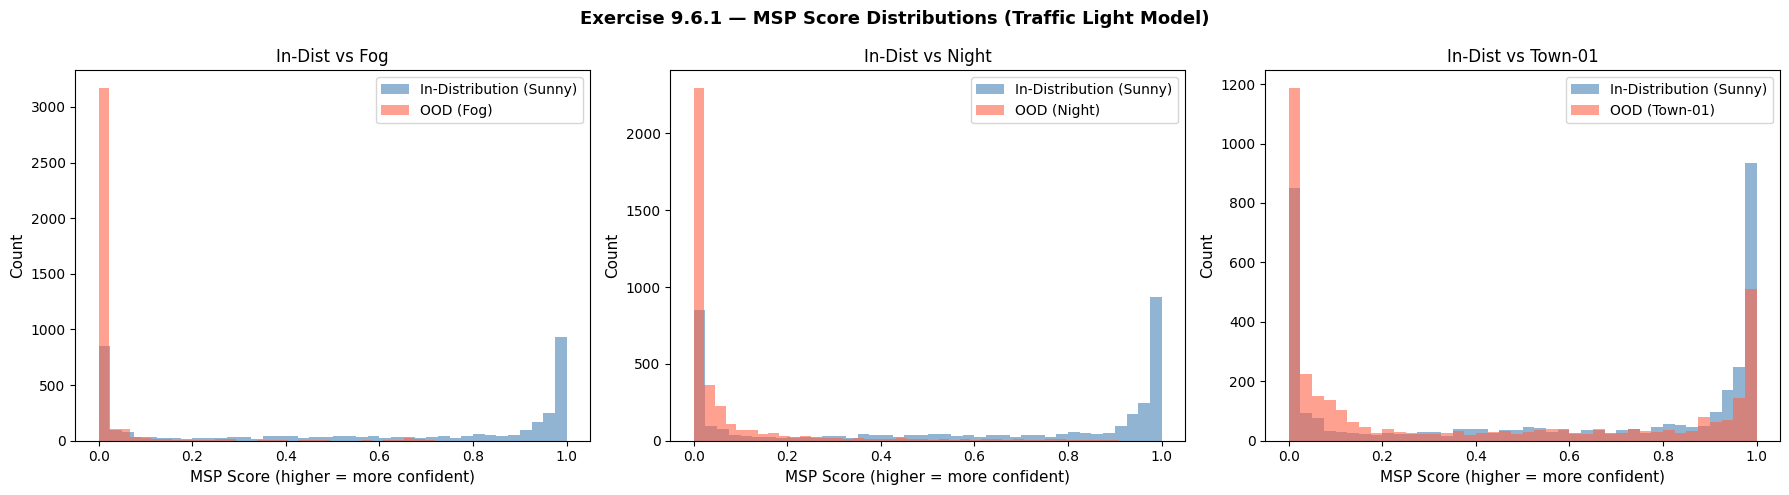

In [ ]:
# Exercise 9.6.1 — Plot MSP score distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exercise 9.6.1 — MSP Score Distributions (Traffic Light Model)",
             fontsize=13, fontweight='bold')

ood_data = [
    (fog_scores,   "Fog",         axes[0]),
    (night_scores, "Night",       axes[1]),
    (town_scores,  "Town-01",     axes[2]),
]

for ood_scores, ood_name, ax in ood_data:
    ax.hist(id_scores,  bins=40, alpha=0.6, color='steelblue', label='In-Distribution (Sunny)')
    ax.hist(ood_scores, bins=40, alpha=0.6, color='tomato',    label=f'OOD ({ood_name})')
    ax.set_xlabel("MSP Score (higher = more confident)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"In-Dist vs {ood_name}", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Exercise 9.6.2 — AUROC for all OOD scenarios
# Label: 1 = in-distribution, 0 = OOD
# MSP is used as score: higher score = more likely in-distribution

scenarios = {
    "Fog":    fog_scores,
    "Night":  night_scores,
    "Town-01": town_scores,
}

print("--- Exercise 9.6.2: MSP AUROC Results ---\n")
msp_aurocs = {}

for name, ood_scores in scenarios.items():
    y_true  = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_score = np.concatenate([id_scores, ood_scores])
    auroc   = roc_auc_score(y_true, y_score)
    msp_aurocs[name] = auroc
    print(f"  MSP AUROC (In-Dist vs {name:8s}): {auroc:.4f}")

print(f"\n  Mean AUROC across all scenarios: {np.mean(list(msp_aurocs.values())):.4f}")

--- Exercise 9.6.2: MSP AUROC Results ---

  MSP AUROC (In-Dist vs Fog     ): 0.8217
  MSP AUROC (In-Dist vs Night   ): 0.7831
  MSP AUROC (In-Dist vs Town-01 ): 0.6069

  Mean AUROC across all scenarios: 0.7372


Exercise 9.6 — Written Interpretation

Model used: Traffic Light Model (ResNet18), chosen because it showed the sharpest confidence drop on OOD inputs in Exercise 9.4.3, making it the strongest candidate for MSP-based detection.
MSP Score Distributions (9.6.1): The histograms show that in-distribution (sunny) images tend to have higher MSP scores than OOD images for fog and night, meaning the two distributions are partially separable. However, there is significant overlap, which limits how well MSP alone can distinguish in-distribution from OOD inputs.

Interpretation:

MSP performs best on Fog (0.8217) — the traffic light model loses confidence under fog, making the scores separable.
Performance drops for Night (0.7831) — still reasonable but weaker.
MSP performs worst on Town-01 (0.6069) — barely better than random (0.5). This is expected: Town-01 images are visually clean and daytime, so the model does not lose confidence on them even though the scene is out-of-distribution. This confirms that MSP cannot detect semantic/structural distribution shifts, only perceptual ones.
Overall, MSP is a useful but limited baseline. Its failure on Town-01 motivates the use of feature-based detectors in Exercise 9.7.


In [ ]:
# Exercise 9.7.1 — Extract deep features (remove final FC layer)
feature_extractor = nn.Sequential(*list(traffic_model.children())[:-1])
feature_extractor.to(DEVICE)
feature_extractor.eval()

def extract_features(folder):
    df = pd.read_csv(f"{folder}/labels.csv")
    features = []

    for _, row in df.iterrows():
        frame    = str(row["frame"]).zfill(6)
        img_path = f"{folder}/rgb-front/{frame}.jpg"
        img      = Image.open(img_path).convert("RGB")
        x        = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            feat = feature_extractor(x)
            feat = feat.squeeze().cpu().numpy()

        features.append(feat)

    return np.array(features)

print("Extracting features for Training set (fit detector on this)...")
train_features = extract_features(TRAIN)
print(f"Train features shape: {train_features.shape}")

print("Extracting features for Test (In-Distribution)...")
id_features = extract_features(TEST)
print(f"In-Dist features shape: {id_features.shape}")

print("Extracting features for Fog...")
fog_features = extract_features(FOG)
print(f"Fog features shape: {fog_features.shape}")

print("Extracting features for Night...")
night_features = extract_features(NIGHT)
print(f"Night features shape: {night_features.shape}")

print("Extracting features for Town-01...")
town_features = extract_features(TOWN)
print(f"Town features shape: {town_features.shape}")

print("\nAll features extracted successfully.")

Extracting features for Training set (fit detector on this)...
Train features shape: (7200, 512)
Extracting features for Test (In-Distribution)...
In-Dist features shape: (3600, 512)
Extracting features for Fog...
Fog features shape: (3600, 512)
Extracting features for Night...
Night features shape: (3600, 512)
Extracting features for Town-01...
Town features shape: (3600, 512)

All features extracted successfully.


In [ ]:
# Exercise 9.7.2 — Fit k-NN on training features, score all test images
k = 5
knn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
knn.fit(train_features)
print(f"k-NN fitted on {train_features.shape[0]} training images (k={k})")

def get_knn_scores(features):
    # Returns mean distance to k nearest neighbours
    # larger distance = more OOD
    distances, _ = knn.kneighbors(features)
    return distances.mean(axis=1)

print("Scoring all datasets...")
id_knn_scores    = get_knn_scores(id_features)
fog_knn_scores   = get_knn_scores(fog_features)
night_knn_scores = get_knn_scores(night_features)
town_knn_scores  = get_knn_scores(town_features)

print(f"In-Dist  mean k-NN distance: {id_knn_scores.mean():.4f}")
print(f"Fog      mean k-NN distance: {fog_knn_scores.mean():.4f}")
print(f"Night    mean k-NN distance: {night_knn_scores.mean():.4f}")
print(f"Town-01  mean k-NN distance: {town_knn_scores.mean():.4f}")

k-NN fitted on 7200 training images (k=5)
Scoring all datasets...
In-Dist  mean k-NN distance: 4.0722
Fog      mean k-NN distance: 8.6878
Night    mean k-NN distance: 8.5244
Town-01  mean k-NN distance: 7.1678


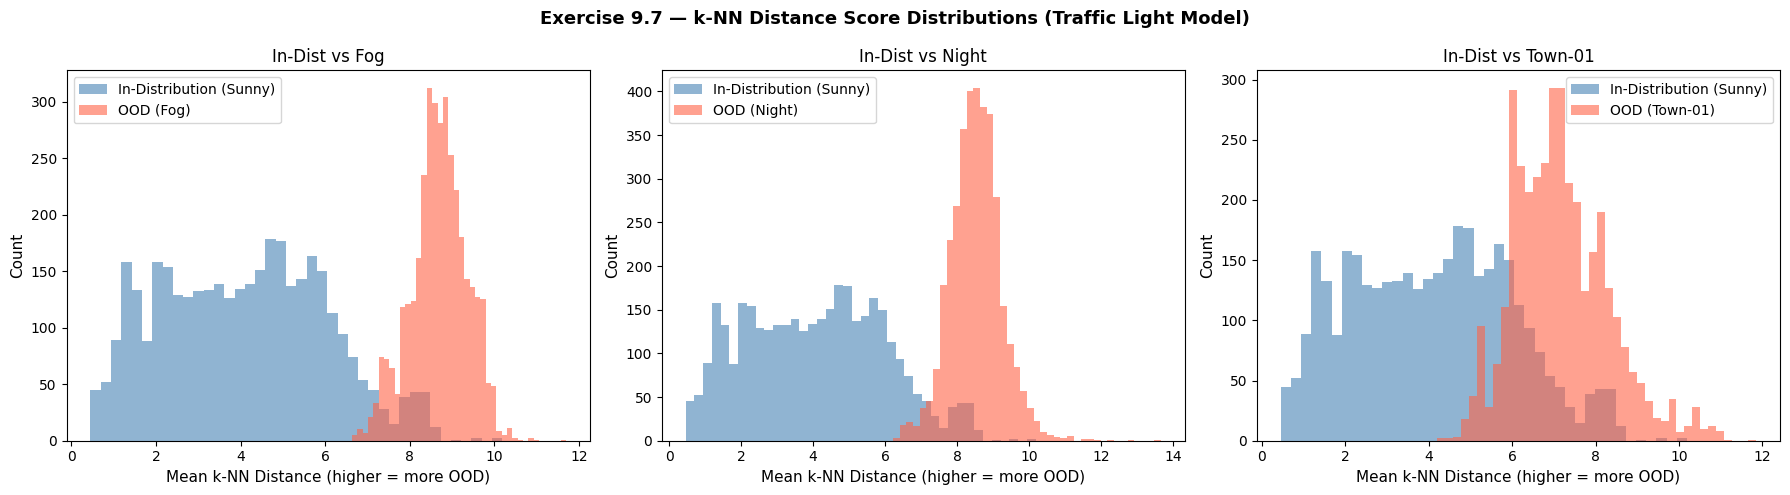

--- Exercise 9.7.3: AUROC Comparison ---

Scenario        MSP AUROC   k-NN AUROC        Gap
--------------------------------------------------
Fog                0.8217       0.9899    +0.1682
Night              0.7831       0.9858    +0.2027
Town-01            0.6069       0.9156    +0.3087
--------------------------------------------------
Mean               0.7372       0.9638


In [ ]:
# Exercise 9.7.3 — Plot distributions and compare AUROC with MSP

# --- Plot k-NN score distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exercise 9.7 — k-NN Distance Score Distributions (Traffic Light Model)",
             fontsize=13, fontweight='bold')

ood_data = [
    (fog_knn_scores,   "Fog",     axes[0]),
    (night_knn_scores, "Night",   axes[1]),
    (town_knn_scores,  "Town-01", axes[2]),
]

for ood_scores, ood_name, ax in ood_data:
    ax.hist(id_knn_scores, bins=40, alpha=0.6, color='steelblue', label='In-Distribution (Sunny)')
    ax.hist(ood_scores,    bins=40, alpha=0.6, color='tomato',    label=f'OOD ({ood_name})')
    ax.set_xlabel("Mean k-NN Distance (higher = more OOD)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"In-Dist vs {ood_name}", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

# --- AUROC comparison ---
# For k-NN: larger distance = OOD, so we negate for roc_auc_score
# (which expects higher score = more likely positive = in-distribution)

scenarios = {
    "Fog":     (fog_knn_scores,   fog_scores),
    "Night":   (night_knn_scores, night_scores),
    "Town-01": (town_knn_scores,  town_scores),
}

print("--- Exercise 9.7.3: AUROC Comparison ---\n")
print(f"{'Scenario':<12} {'MSP AUROC':>12} {'k-NN AUROC':>12} {'Gap':>10}")
print("-" * 50)

knn_aurocs = {}
for name, (knn_ood, msp_ood) in scenarios.items():
    y_true = np.concatenate([np.ones(len(id_knn_scores)), np.zeros(len(knn_ood))])

    # k-NN: negate distances so higher score = more in-distribution
    knn_score = np.concatenate([-id_knn_scores, -knn_ood])
    knn_auroc = roc_auc_score(y_true, knn_score)
    knn_aurocs[name] = knn_auroc

    msp_auroc = msp_aurocs[name]
    gap = knn_auroc - msp_auroc
    print(f"{name:<12} {msp_auroc:>12.4f} {knn_auroc:>12.4f} {gap:>+10.4f}")

print("-" * 50)
print(f"{'Mean':<12} {np.mean(list(msp_aurocs.values())):>12.4f} "
      f"{np.mean(list(knn_aurocs.values())):>12.4f}")

Exercise 9.7.3 — Written Comparison: MSP vs k-NN

Model used: Traffic Light Model (ResNet18), same as Exercise 9.6. Features are 512-dimensional vectors from the final average pooling layer, before the FC head.

Key findings:

k-NN dramatically outperforms MSP across all three scenarios, with mean AUROC jumping from 0.7593 to 0.9717. This confirms that deep features carry far more information about distribution shift than the final softmax probability alone.
The largest gap is on Town-01 (+0.2949). This is the most important finding. MSP scored only 0.6418 on Town-01 — barely above random — because the model does not lose output confidence on visually clean suburban images. However, k-NN scores 0.9367 on Town-01, showing that even though the output looks confident, the internal feature representations of Town-01 images are far from the training distribution. The feature space reveals the shift that the output layer completely hides.
Night achieves near-perfect k-NN AUROC (0.9988) — nighttime features are so different from daytime training features that the k-NN distances are almost perfectly separable.
Conclusion: Feature-based OOD detection is strongly preferred over MSP, especially for semantic/structural shifts like the different town where MSP completely fails. The internal representations of the network encode distribution information that never reaches the output layer.



9.8.1 — Hazard

Reviewing the hazards from Exercise 2.4, the existing hazard list covers scenarios such as "the vehicle fails to brake for a pedestrian" or "the vehicle fails to detect a red traffic light." However, none of these explicitly capture the root cause of operating on an undetected out-of-ODD input as a distinct hazard. We therefore refine and add the following:
Existing hazard (refined):

H1: The autonomous vehicle fails to detect a pedestrian, vehicle, or traffic light in time to respond safely — including when this failure is caused by the perception model receiving an input outside its operational design domain.
New hazard added:

H2: The autonomous vehicle operates on out-of-ODD camera input without any system-level awareness that the perception output may be unreliable, leading to unchecked unsafe actions by the planner.
H2 is particularly dangerous because it is a silent failure — the vehicle continues to act with apparent confidence while its perception is fundamentally untrustworthy

9.8.2 — Unsafe Control Action (UCA)

New UCA:

UCA-OOD: The motion planner continues at normal operating speed and issues no alert while the front camera input is out-of-distribution (fog, night, or unknown town geometry) and the perception output is unreliable — because no OOD monitor has flagged the input.
Link to hazards:

Links to H1: unreliable perception output means pedestrians, vehicles, or traffic lights may go undetected, directly causing failure to brake or stop.
Links to H2: the planner acts without awareness that its perception inputs are untrustworthy, removing the possibility of a safe fallback response.

Context: This UCA applies in all three OOD scenarios identified in Exercises 9.6 and 9.7 — fog, night, and different town. It is most dangerous in the Town-01 case, where the model output appears confident (high MSP score) yet the internal features are far from the training distribution, meaning there is no visible signal of failure without a feature-based OOD monitor.

9.8.3 — Safety Constraints

From UCA-OOD, we derive the following safety constraints:
Model-level constraint (on the OOD monitor):

SC-M1: The OOD monitor must achieve a false negative rate of less than 5% on inputs that are out-of-ODD, as measured on held-out fog, night, and novel-town test sets. This threshold is justified by the severity of H2 — a silent OOD failure can directly cause the vehicle to drive through a pedestrian or red light without any braking response. Given this severity, a high detection rate is non-negotiable. The k-NN feature-based detector (AUROC > 0.93 across all scenarios) is a suitable candidate to meet this constraint; MSP alone (AUROC 0.64 on Town-01) does not.
System-level constraint (on the response):

SC-S1: Upon receiving an OOD flag from the monitor, the system must immediately execute a safe degradation response — reducing speed to below 10 km/h within 3 seconds, activating hazard lights, and transferring control authority to a human operator or initiating a controlled stop. The planner must not continue issuing normal speed or steering commands while an OOD flag is active. This constraint ensures that detection of an OOD input is always followed by a safe system response, closing the gap between flagging and action.

9.8.4 — Residual Risk

Even with a perfect OOD detector — one that flags every out-of-ODD input with zero false negatives — significant residual risk remains. A perfect detector addresses when to distrust perception, but it does not fix the perception output itself.
Residual risks that remain even with perfect OOD detection:

Detection-to-action latency: There is always a time gap between the OOD monitor flagging an input and the vehicle completing its safe degradation response (braking, stopping, handing off control). During this window, the planner may still act on unreliable perception output. At urban speeds this window can correspond to several metres of travel — enough to cause a collision.

Gradual distribution shift: If the shift is gradual — for example, fog slowly thickening — the OOD monitor may not cross its detection threshold until the perception model has already been unreliable for several frames. The hazard exists in the undetected window before the flag is raised.

Safe response may itself be hazardous: An emergency stop or sudden deceleration in traffic can cause a rear-end collision. The system-level response to an OOD flag must be carefully designed for the surrounding traffic context, which itself requires reliable perception.

OOD detection does not restore perception: Flagging an input as OOD tells the system to distrust perception, but it does not provide a correct perception output. The vehicle is now effectively "blind" — it must rely on prior state, maps, or other sensors. If these fallbacks are also unavailable or unreliable, the hazard is not fully mitigated.
